# Experiment 1

Idea: With a given probability randomly allocate price within the range otherwise give
best action as suggested by policy

In [1]:
import gymnasium as gym
import pandas as pd
import numpy as np
from stable_baselines3.ppo import PPO
import seaborn as sns
import matplotlib.pyplot as plt
import copy

from fair_dynamic_pricing_with_rl.utils.env import FMCGEnv
from fair_dynamic_pricing_with_rl.utils.demand_model import DemandModelEstimator

In [2]:
unit_sales = pd.read_csv("../data/sales_train_evaluation.csv")
prices = pd.read_csv("../data/sell_prices.csv")
calendar = pd.read_csv("../data/calendar.csv")

In [ ]:
demand_model_estimator = DemandModelEstimator(
    unit_sales_df = unit_sales,
    prices_df = prices,
    calendar_df = calendar,
    price_granularity = 0.001,
    verbose = True
)

demand_model_parameters = demand_model_estimator.run_pipeline()

--- Fitting demand model for FOODS_1_096 ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     325.1
Date:                Fri, 24 Jul 2026   Prob (F-statistic):          1.13e-279
Time:                        07:58:52   Log-Likelihood:                -3366.3
No. Observations:                1300   AIC:                             6749.
Df Residuals:                    1292   BIC:                             6790.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [4]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/FMCGEnv",
    entry_point=FMCGEnv,
    max_episode_steps=500,  # Prevent infinite episodes
)

In [5]:
env = gym.make("gymnasium_env/FMCGEnv",
               p_min=aids_parameters[0],
               p_max=aids_parameters[1],
               p_diff=aids_parameters[2],
               betas=aids_parameters[3],
                max_demand=aids_parameters[4],
                n_snap_days=10,
                calendar_seed=42,
               noise_range=1
               )

In [6]:
# PPO hyperparameters from Liu et al. (2024)
model = PPO(policy="MultiInputPolicy",
            env=env,
            learning_rate=0.0001,
            batch_size=64, # default
            clip_range=0.2, # default
            seed=42)

# no warm-up
# model.learn(total_timesteps=25000,
#            progress_bar=True)

In [7]:
def running_model(env1,
                  alg,
                  T,
                  K,
                  num_products,
                  random_action_prob=0.5,
                  seed=None
                  ):
    """ Policy choosing for K episodes of length T.
    """

    env = copy.deepcopy(env1)

    # dedicated RNG for random action override plus seeding action sampler
    rng = np.random.default_rng(seed)
    env.action_space.seed(seed)

    rew = np.zeros((T,K))
    action_hist = np.zeros((T,K,num_products))
    groups = np.zeros((T,K))

    for k in range(K):
        # sample initial state
        # seed each reset deterministically but distinctly per episode
        observation, info = env.reset(seed=None if seed is None else seed + k)

        #record reward received over episode
        eprew = 0.0
        for t in range(T):
            # save the group wrt. sensitive attribute
            groups[t,k] = observation['sensitive_attr']
            
            # take action using trained model
            action, _states = alg.predict(observation, deterministic=False)
            a = np.asarray(action)
            
            # with random_action_prob override with a random action
            if rng.random() < random_action_prob:
                a = env.action_space.sample()
                a = np.asarray(a)
            
            action_hist[t,k] = a

            # record new state/reward from action played
            observation, reward, terminated, truncated, info = env.step(a)
            eprew += reward

            rew[t,k] = reward
        
    return rew, action_hist, groups

In [10]:
rewards, action_hist, groups = running_model(env1=env,
                                             alg=model,
                                             T= 52,
                                             K=1000,
                                             num_products=2,
                                             random_action_prob=0.5,
                                             seed=42)

c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\utils\passive_env_checker.py:129: UserWarning: WARN: The obs returned by the `reset()` method was expecting a numpy array, actual type: <class 'pandas.core.series.Series'>
  logger.warn(
c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\spaces\box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")
c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\utils\passive_env_checker.py:129: UserWarning: WARN: The obs returned by the `step()` method was expecting a numpy array, actual type: <class 'pandas.core.series.Series'>
  logger.warn(
c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\spaces\box.py:415: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


In [18]:
episode_rewards

array([3848.55094142, 4202.50943036, 4293.61438333, 4120.67320467,
       3556.1326162 , 4174.13175808, 4352.44339499, 4086.7154035 ,
       4585.52936395, 3918.22539016, 4390.7773227 , 4328.53120795,
       4513.16888617, 3968.03056875, 4686.68852845, 5001.13082108,
       4160.61512738, 4154.68101436, 4349.18921154, 4398.04069458,
       4167.49047304, 4708.93704373, 4514.32028091, 4022.78720087,
       4614.97834012, 4001.60617251, 4456.96741204, 4203.55057745,
       4045.41546102, 3915.85685038, 4445.220675  , 3921.5063085 ,
       4292.61348583, 5002.45977273, 3940.76041063, 4160.09961976,
       3348.59410524, 4378.9029812 , 4400.47314876, 3875.71692354,
       4042.86504637, 4749.28754173, 3789.74183354, 3712.04646469,
       4383.56229867, 3970.07415824, 3393.96319138, 4525.19853108,
       4105.50347396, 4331.61562084, 3525.56855898, 4506.93811723,
       4317.6363328 , 4832.51621859, 3925.9715898 , 4802.679154  ,
       4364.23444516, 4665.15290495, 4176.50562591, 4677.47473

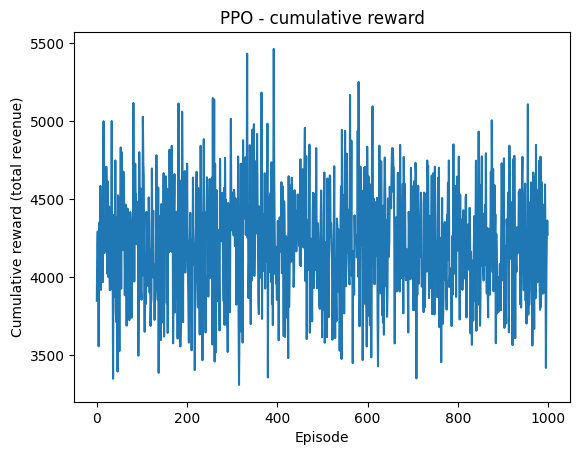

In [ ]:
episode_rewards = rewards.sum(axis=0)

sns.lineplot(episode_rewards.cumsum()[:10])
plt.xlabel("Episode")
plt.ylabel("Cumulative reward (total revenue)")
plt.title("PPO - cumulative reward")
plt.show()

In [10]:
def compute_jains_index(env, action_hist, groups, rew, metric="revenue"):
    """
    Compute Jain's fairness index across sensitive-attribute (SNAP-proxied) groups.

    Args:
        env: FMCGEnv instance — only used for its `_action_to_price` method
        action_hist: array (H, T, L) of raw action indices taken by the policy
        groups: array (H, T) of sensitive attribute labels (0/1)
        rew: array (H, T) of realized rewards (already p @ demand)
        metric: "revenue" -> use realized reward directly per group
                "price"   -> recompute prices from actions and aggregate
                             mean total basket price per group

    Returns:
        jains_index: float
        group_values: dict {group_label: aggregated_value}
    """
    unique_groups = np.unique(groups)
    group_values = {}

    if metric == "revenue":
        for g in unique_groups:
            mask = (groups == g)
            group_values[g] = rew[mask].mean()

    elif metric == "price":
        H, T, L = action_hist.shape
        prices = np.zeros((H, T, L))
        for t in range(T):
            for h in range(H):
                prices[h, t, :] = env._action_to_price(action_hist[h, t, :])

        total_price = prices.sum(axis=2)  # basket price per (h, t)

        for g in unique_groups:
            mask = (groups == g)
            group_values[g] = total_price[mask].mean()

    else:
        raise ValueError("metric must be 'revenue' or 'price'")

    x = np.array(list(group_values.values()))
    n = len(x)
    jains_index = (x.sum() ** 2) / (n * np.sum(x ** 2))

    return jains_index, group_values

In [11]:
j_revenue, gv_rev = compute_jains_index(env, action_hist, groups, rewards, metric="revenue")
j_price,   gv_pr  = compute_jains_index(env, action_hist, groups, rewards, metric="price")

print(f"Jain's index (revenue-based): {j_revenue:.4f}")
print(f"Jain's index (price-based):   {j_price:.4f}")

AttributeError: 'TimeLimit' object has no attribute '_action_to_price'